In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/shivamb/netflix-shows/netflix_titles.csv


In [2]:
import kagglehub
import pandas as pd
import matplotlib.pyplot as plt

# 1. Download dataset netflix otomatis
path = kagglehub.dataset_download("shivamb/netflix-shows")

# 2. Baca file csv dari path hasil download
df = pd.read_csv(f"{path}/netflix_titles.csv")

# 3. Tampilkan data
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


### Penjelasan Data:
Tampilan di atas menunjukkan **5 baris pertama** dari dataset Netflix. Tabel ini memberikan gambaran umum tentang struktur data yang kita miliki, antara lain:
* **`type`**: Jenis konten (Movie atau TV Show).
* **`title`**: Judul film atau acara TV.
* **`director` & `cast`**: Sutradara dan daftar pemain.
* **`country`**: Negara asal pembuat konten.
* **`release_year`**: Tahun rilis konten.
* **`rating`**: Batasan usia penonton (seperti TV-MA, PG-13, dll).

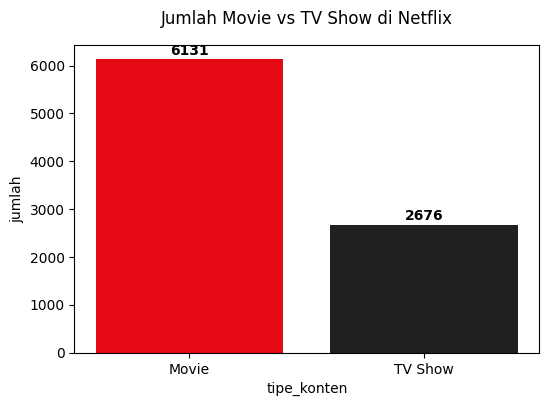

In [3]:
tipe_konten = df['type'].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(tipe_konten.index, tipe_konten.values, color=['#e50914', '#221f1f'])
plt.title('Jumlah Movie vs TV Show di Netflix', fontsize=12, pad=15)
plt.xlabel('tipe_konten')
plt.ylabel('jumlah')

for i, v in enumerate(tipe_konten.values):
    plt.text(i, v + 100, str(v), ha='center', fontweight='bold')

plt.show()

### 2. Perbandingan Tipe Konten (Movie vs TV Show)

Grafik batang di atas menunjukkan perbandingan jumlah konten berdasarkan tipenya di Netflix:
* **Movie (Film):** Mendominasi perpustakaan Netflix dengan total **6.131 judul** (sekitar 69.6%).
* **TV Show (Serial TV):** Berjumlah **2.676 judul** (sekitar 30.4%).

**Insight:** Netflix memiliki koleksi Film lebih dari dua kali lipat dibandingkan Serial TV.

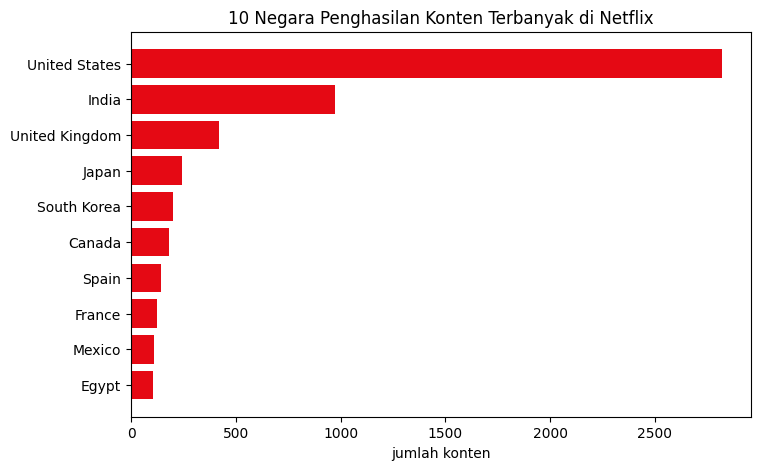

In [4]:
top_negara = df['country'].value_counts().head(10)

plt.figure(figsize=(8, 5))
plt.barh(top_negara.index, top_negara.values, color='#e50914')
plt.title('10 Negara Penghasilan Konten Terbanyak di Netflix', fontsize=12)
plt.xlabel('jumlah konten')

plt.gca().invert_yaxis()

### 3. Top 10 Negara Penghasil Konten Terbanyak

Grafik batang horizontal di atas menunjukkan negara-negara penyumbang konten terbanyak di Netflix:
* **Amerika Serikat (United States):** Menjadi produsen konten terbesar dengan jumlah yang jauh melampaui negara lain (lebih dari 2.500 judul).
* **India:** Berada di posisi kedua (sekitar 1.000 judul), didorong oleh banyaknya industri film Bollywood.
* **United Kingdom & Asia (Jepang, Korea Selatan):** Mengisi posisi berikutnya, menunjukkan tingginya popularitas anime dan K-Drama di platform ini.

**Insight:** Mayoritas konten di Netflix didominasi oleh produksi Amerika Serikat, diikuti oleh industri hiburan besar dari Asia seperti India, Jepang, dan Korea Selatan.

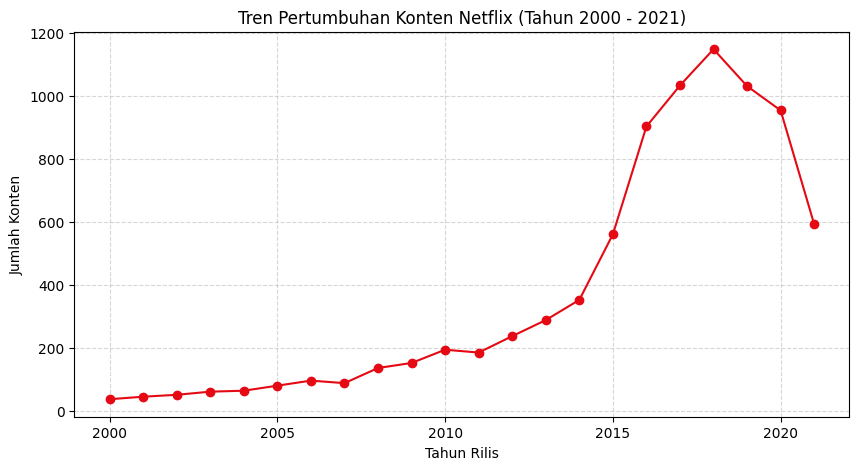

In [5]:
tahun_rilis = df['release_year'].value_counts().sort_index()

tahun_rilis_2000 = tahun_rilis[tahun_rilis.index >= 2000]

plt.figure(figsize=(10, 5))
plt.plot(tahun_rilis_2000.index, tahun_rilis_2000.values, color='#e50914', marker='o')
plt.title('Tren Pertumbuhan Konten Netflix (Tahun 2000 - 2021)', fontsize=12)
plt.xlabel('Tahun Rilis')
plt.ylabel('Jumlah Konten')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

### 4. Tren Pertumbuhan Rilis Konten (2000 - 2021)

Grafik garis di atas menggambarkan perkembangan jumlah rilis konten yang ada di Netflix dari tahun 2000 hingga 2021:
* **2000 - 2013:** Pertumbuhan cenderung landai karena Netflix masih berfokus pada layanan penyewaan DVD dan awal mula ekspansi *streaming*.
* **2015 - 2018:** Terjadi lonjakan ekponensial yang sangat signifikan, menandai periode keemasan ekspansi global Netflix dan produksi *Netflix Originals*.
* **Puncak (2018–2019):** Rilis konten mencapai titik tertinggi dengan lebih dari 1.000 judul rilis dalam kurun waktu tersebut.
* **Penurunan (2020–2021):** Terlihat adanya penurunan jumlah rilis, yang dipengaruhi oleh restriksi pandemi global terhadap industri produksi film.

**Insight:** Netflix mengalami ekspansi katalog yang sangat pesat mulai tahun 2015 sebelum akhirnya melambat di masa pandemi.

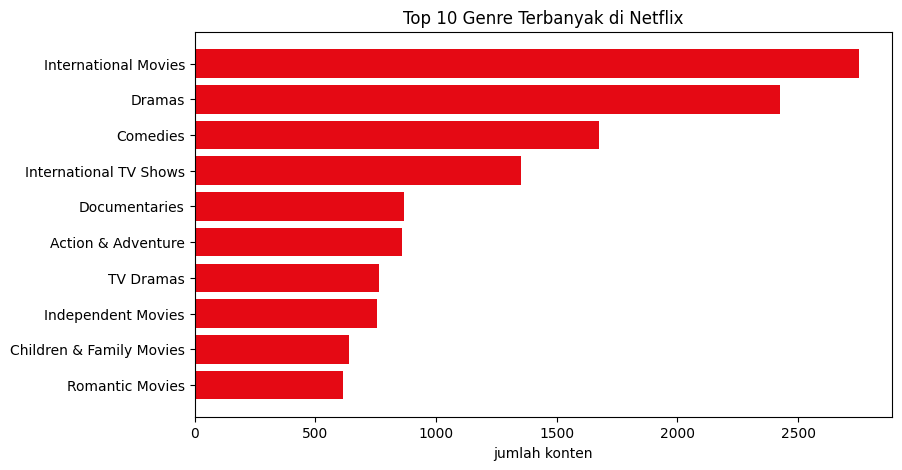

In [6]:
genre = df['listed_in'].str.split(', ').explode().value_counts().head(10)

plt.figure(figsize=(9, 5))
plt.barh(genre.index, genre.values, color='#e50914')
plt.title('Top 10 Genre Terbanyak di Netflix', fontsize=12)
plt.xlabel('jumlah konten')
plt.gca().invert_yaxis()

plt.show()

### 5. Top 10 Genre Terbanyak di Netflix

Grafik batang horizontal di atas menampilkan 10 kategori/genre konten paling populer yang tersedia di Netflix:
* **International Movies & Dramas:** Menduduki posisi teratas dengan jumlah terbanyak (mendekati 2.800 dan 2.500 judul), menunjukkan fokus Netflix pada tayangan drama serta konten global.
* **Comedies:** Berada di posisi ketiga sebagai salah satu genre hiburan utama yang sangat diminati penonton.
* **International TV Shows & Documentaries:** Mengisi peringkat berikutnya, mempertegas keberagaman format tayangan di platform ini.

**Insight:** Konten bertema Drama, Film Internasional, dan Komedi menjadi pilar utama perpustakaan media Netflix.

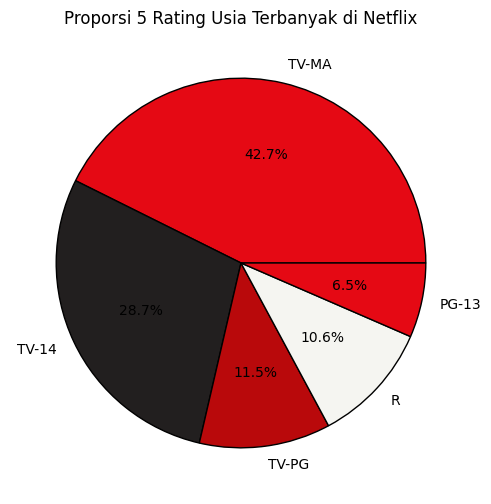

In [7]:
top_rating = df['rating'].value_counts().head(5)

plt.figure(figsize=(6, 6))
plt.pie(top_rating.values, labels=top_rating.index, autopct='%1.1f%%',
        colors=['#e50914', '#221f1f', '#b9090b', '#f5f5f1', '#e50914'],
        wedgeprops={'edgecolor': 'black'})

plt.title('Proporsi 5 Rating Usia Terbanyak di Netflix', fontsize=12)
plt.show()

### 6. Distribusi Rating Batasan Usia Konten

Grafik lingkaran di atas menunjukkan pembagian proporsi rating usia penonton untuk konten di Netflix:
* **TV-MA (Dewasa/17+):** Paling mendominasi dengan proporsi sebesar **42.7%**.
* **TV-14 (Remaja/14+):** Menduduki porsi terbesar kedua setelah TV-MA.
* **TV-PG (Bimbingan Orang Tua) & R (Dewasa):** Masing-masing menyumbang **11.5%** dan **10.6%**.
* **PG-13 (Bimbingan Orang Tua untuk <13 tahun):** Menyumbang sebesar **6.5%**.

**Insight:** Mayoritas konten di Netflix ditargetkan untuk penonton usia dewasa dan remaja (TV-MA & TV-14), sedangkan konten ramah keluarga/anak-anak memiliki porsi yang lebih kecil.

## 7. Kesimpulan (Executive Summary)

Berdasarkan analisis dan visualisasi data yang telah dilakukan, dapat disimpulkan beberapa poin utama mengenai katalog Netflix:

* **Dominasi Tipe Konten:** Katalog Netflix didominasi oleh Movie (**6.131 judul**) dibandingkan TV Show (**2.676 judul**).
* **Pasar Utama:** **United States** dan **India** merupakan dua negara produsen konten terbesar di platform ini.
* **Target Penonton:** Mayoritas konten ditujukan untuk audiens dewasa, dipimpin oleh rating **TV-MA (42.7%)**.
* **Genre Populer:** **International Movies**, **Dramas**, dan **Comedies** adalah genre yang paling banyak diproduksi.
*

### 8. Rekomendasi Bisnis (Business Recommendations)

Berdasarkan temuan analisis data katalog Netflix, berikut adalah beberapa rekomendasi strategis yang dapat dipertimbangkan:

* **Investasi Lebih Pada Konten TV Show (Serial):**
  * *Alasan:* Meskipun katalog didominasi oleh Movie (6.131 judul vs 2.676 TV Show), TV Show memiliki tingkat retensi penonton (*watch time*) yang lebih tinggi.
  * *Aksi:* Tingkatkan akuisisi dan produksi *Original Series* untuk menjaga angka langganan bulanan (*subscriber retention*).

* **Diversifikasi Konten untuk Audiens Keluarga & Remaja:**
  * *Alasan:* Mayoritas konten saat ini ditujukan untuk audiens dewasa (TV-MA sebesar 42,7%).
  * *Aksi:* Tambah porsi konten berating **PG-13 / TV-14** atau **Kids** untuk menjangkau pangsa pasar keluarga.

* **Ekspansi Lisensi & Produksi Konten Lokal:**
  * *Alasan:* Amerika Serikat dan India menjadi produsen terbesar, sementara genre *International Movies* sangat populer.
  * *Aksi:* Tingkatkan kolaborasi dengan studio lokal di wilayah potensial (seperti Asia Tenggara & Latin America).